# 09 — Possession Sequence EDA

**Frame2Threat v2** | Exploratory analysis of `possession_sequences.parquet`

Covers all 32 columns across five sections:

| Section | Focus |
|---|---|
| §1 | Dataset overview & data quality |
| §2 | Possession structure (length, duration, event mix) |
| §3 | Spatial patterns (territory, start zones, pitch maps) |
| §4 | All labels — prevalence, interactions, outcome tier |
| §5 | Tactical: phase, tempo, verticality, recycling |
| §6 | Team / competition profiles |
| §7 | Sequence-level: event type distributions per step |

## 0. Imports & paths

In [1]:
import sys, os, warnings
from pathlib import Path

_cwd = Path(".").resolve()
PROJECT_ROOT = _cwd if (_cwd / "src").exists() else _cwd.parent
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
import seaborn as sns
from mplsoccer import Pitch, VerticalPitch

from src.data.parse_possessions import load_possession_sequences
from src.labels.possession_labels import attach_possession_labels, LABEL_DEFINITIONS

sns.set_theme(style="whitegrid", palette="muted")
SEED = 42
FIG_DIR = Path("reports/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root : {PROJECT_ROOT}")

Project root : C:\Users\USER\Documents\Python Projects\Frame2Threat


## 1. Dataset overview & data quality

In [2]:
# Load structural table + attach all new labels
poss_raw = load_possession_sequences("data/processed/possession_sequences.parquet")
poss     = attach_possession_labels(poss_raw)

print(f"Possessions : {len(poss):,}")
print(f"Matches     : {poss['match_id'].nunique():,}")
print(f"Teams       : {poss['team_name'].nunique():,}")
print(f"Columns     : {poss.shape[1]}")
print()
poss.drop(columns=["event_sequence"]).describe(include="all").T

Possessions : 17,065
Matches     : 99
Teams       : 51
Columns     : 32



,count,unique,top,freq,mean,std,min,25%,50%,75%,max
match_id,17065.0,NaN,NaN,NaN,3830142.17615,41844.13794,3764440.0,3773597.0,3857269.0,3857294.0,3869685.0
possession_id,17065.0,NaN,NaN,NaN,91.393085,55.171737,1.0,45.0,89.0,134.0,274.0
team_name,17065,51,Barcelona,3216,NaN,NaN,NaN,NaN,NaN,NaN,NaN
period,17065.0,NaN,NaN,NaN,1.560035,0.58725,1.0,1.0,2.0,2.0,5.0
origin_type,17065,9,Regular Play,7066,NaN,NaN,NaN,NaN,NaN,NaN,NaN
start_x,16966.0,NaN,NaN,NaN,48.50351,33.161236,0.4,20.0,44.599998,70.0,120.0
start_y,16966.0,NaN,NaN,NaN,40.134983,26.646378,0.1,17.5,40.099998,63.074997,80.0
end_x,15805.0,NaN,NaN,NaN,57.447826,35.779194,0.1,25.700001,60.900002,87.900002,120.0
end_y,15805.0,NaN,NaN,NaN,39.872147,23.625238,0.1,19.299999,40.0,60.299999,80.0
max_x_reached,16966.0,NaN,NaN,NaN,93.406387,21.230093,1.1,80.599998,97.900002,110.199997,120.0


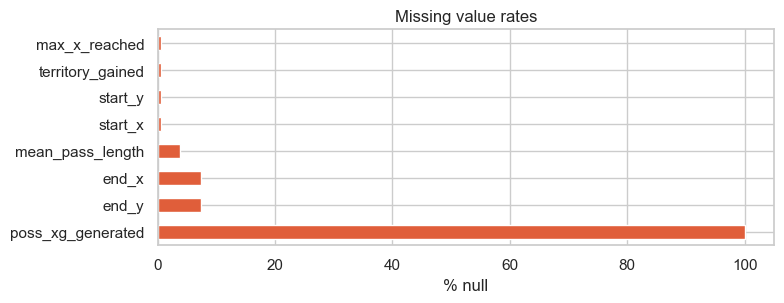

poss_xg_generated    100.000000
end_y                  7.383534
end_x                  7.383534
mean_pass_length       3.832406
start_x                0.580135
start_y                0.580135
territory_gained       0.580135
max_x_reached          0.580135


In [3]:
null_pct = poss.drop(columns=["event_sequence"]).isnull().mean() * 100
null_pct = null_pct[null_pct > 0].sort_values(ascending=False)

if len(null_pct) == 0:
    print("No missing values in any non-sequence column.")
else:
    fig, ax = plt.subplots(figsize=(8, max(3, len(null_pct) * 0.4)))
    null_pct.plot.barh(ax=ax, color="#e05e3a")
    ax.set_xlabel("% null")
    ax.set_title("Missing value rates")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "poss_eda_nulls.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(null_pct.to_string())

## 2. Possession structure — length, duration, event type mix

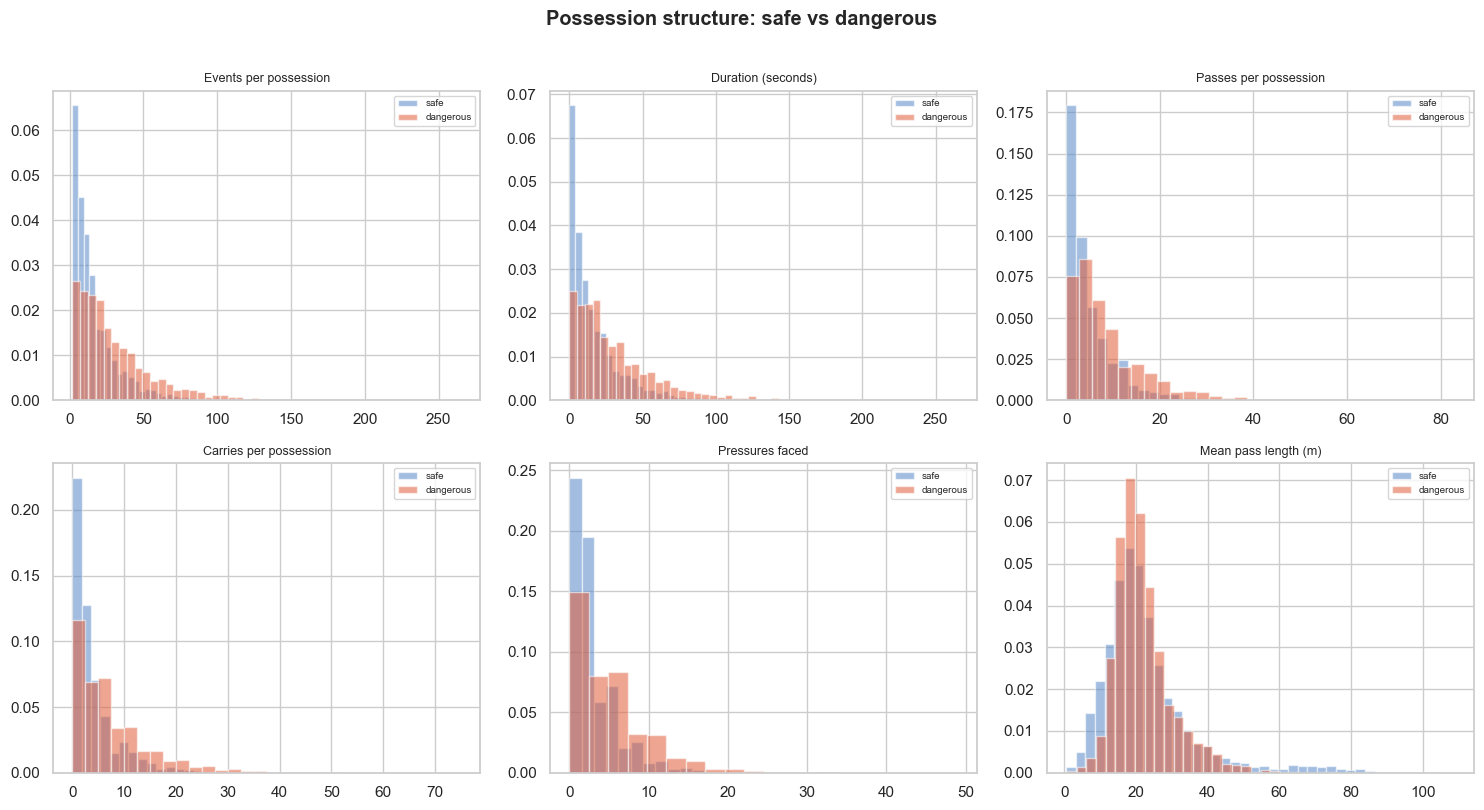

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

specs = [
    ("n_events",       "Events per possession",       50),
    ("duration_seconds", "Duration (seconds)",        50),
    ("n_passes",       "Passes per possession",        30),
    ("n_carries",      "Carries per possession",       30),
    ("n_pressures_faced", "Pressures faced",           20),
    ("mean_pass_length", "Mean pass length (m)",       40),
]

for ax, (col, title, bins) in zip(axes.flat, specs):
    safe = poss[poss["poss_dangerous"] == False][col].dropna()
    dang = poss[poss["poss_dangerous"] == True][col].dropna()
    ax.hist(safe, bins=bins, alpha=0.55, label="safe",      density=True, color="#5688c7")
    ax.hist(dang, bins=bins, alpha=0.55, label="dangerous", density=True, color="#e05e3a")
    ax.set_title(title, fontsize=9)
    ax.legend(fontsize=7)

fig.suptitle("Possession structure: safe vs dangerous", fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / "poss_eda_structure.png", dpi=150, bbox_inches="tight")
plt.show()

In [5]:
# Percentile table for sequence length — key for deciding GRU pad length
pcts = [50, 75, 90, 95, 99, 100]
lens = poss["n_events"]
print("Possession length (n_events) percentiles:")
for p in pcts:
    print(f"  p{p:3d}: {np.percentile(lens, p):.0f} events")
print(f"  Current GRU max_len=40 covers: {(lens <= 40).mean():.1%} of possessions")

Possession length (n_events) percentiles:
  p 50: 15 events
  p 75: 29 events
  p 90: 49 events
  p 95: 66 events
  p 99: 108 events
  p100: 265 events
  Current GRU max_len=40 covers: 85.4% of possessions


## 3. Spatial patterns

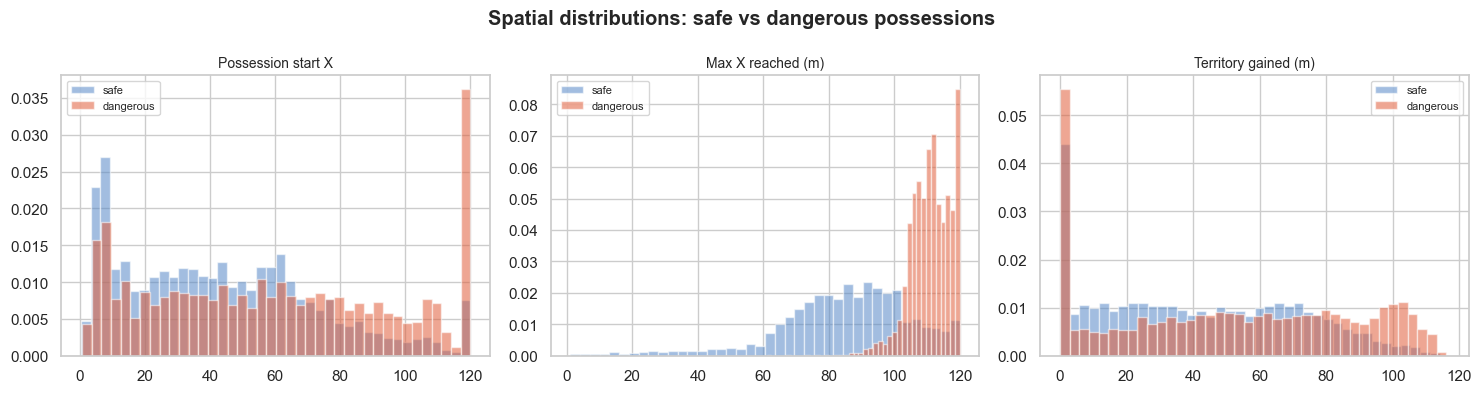

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (col, title) in zip(axes, [
    ("start_x",         "Possession start X"),
    ("max_x_reached",   "Max X reached (m)"),
    ("territory_gained", "Territory gained (m)"),
]):
    safe = poss[poss["poss_dangerous"] == False][col].dropna()
    dang = poss[poss["poss_dangerous"] == True][col].dropna()
    ax.hist(safe, bins=40, alpha=0.55, label="safe",      density=True, color="#5688c7")
    ax.hist(dang, bins=40, alpha=0.55, label="dangerous", density=True, color="#e05e3a")
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle("Spatial distributions: safe vs dangerous possessions", fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "poss_eda_spatial_hists.png", dpi=150, bbox_inches="tight")
plt.show()

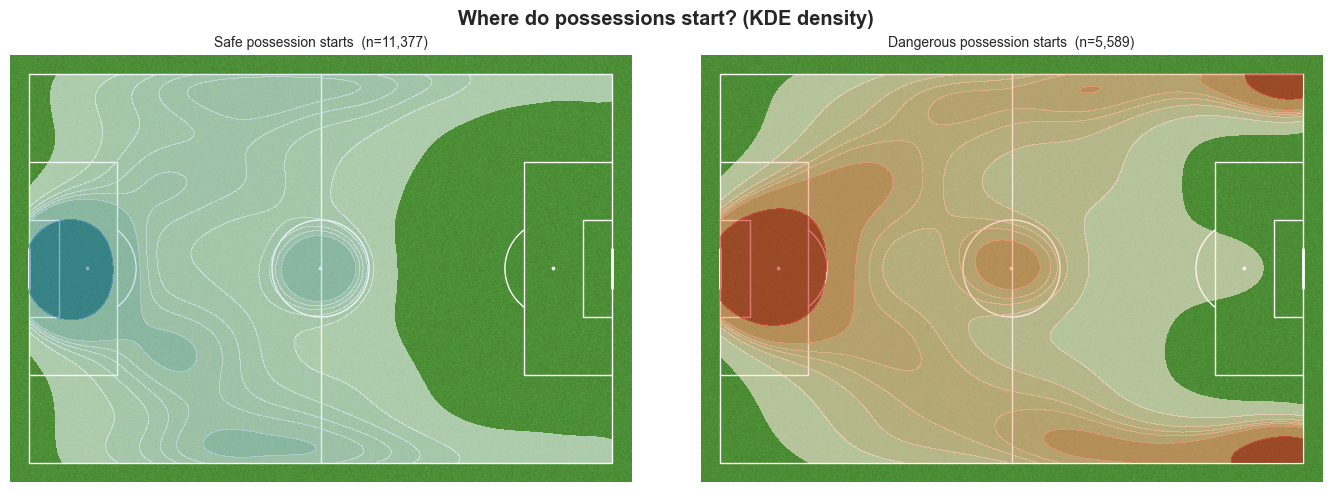

In [7]:
# Possession start locations on pitch — dangerous vs safe
pitch = Pitch(pitch_type="statsbomb", pitch_color="grass", line_color="white", linewidth=1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (mask, title, cmap) in zip(axes, [
    (poss["poss_dangerous"] == False, "Safe possession starts",      "Blues"),
    (poss["poss_dangerous"] == True,  "Dangerous possession starts", "Reds"),
]):
    pitch.draw(ax=ax)
    sub = poss[mask].dropna(subset=["start_x", "start_y"])
    pitch.kdeplot(
        sub["start_x"].values, sub["start_y"].values,
        ax=ax, cmap=cmap, fill=True, alpha=0.6, levels=8,
    )
    ax.set_title(f"{title}  (n={len(sub):,})", fontsize=10)

plt.suptitle("Where do possessions start? (KDE density)", fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "poss_eda_pitch_starts.png", dpi=150, bbox_inches="tight")
plt.show()

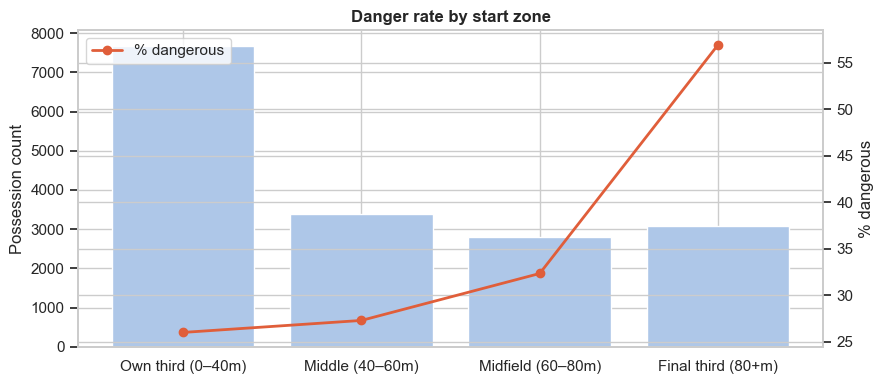

      start_x_zone    n  danger_rate
 Own third (0–40m) 7685     0.259987
   Middle (40–60m) 3397     0.272888
 Midfield (60–80m) 2792     0.323424
Final third (80+m) 3092     0.569534


In [8]:
# Danger rate by start_x bin (pitch thirds)
poss["start_x_zone"] = pd.cut(
    poss["start_x"],
    bins=[0, 40, 60, 80, 120],
    labels=["Own third (0–40m)", "Middle (40–60m)", "Midfield (60–80m)", "Final third (80+m)"],
)

zone_stats = poss.groupby("start_x_zone", observed=True).agg(
    n=("poss_dangerous", "count"),
    danger_rate=("poss_dangerous", "mean"),
).reset_index()

fig, ax1 = plt.subplots(figsize=(9, 4))
bars = ax1.bar(zone_stats["start_x_zone"], zone_stats["n"], color="#aec7e8")
ax2 = ax1.twinx()
ax2.plot(zone_stats["start_x_zone"], zone_stats["danger_rate"] * 100,
         "o-", color="#e05e3a", linewidth=2, label="% dangerous")
ax1.set_ylabel("Possession count")
ax2.set_ylabel("% dangerous")
ax1.set_title("Danger rate by start zone", fontweight="bold")
ax2.legend(loc="upper left")
plt.tight_layout()
plt.savefig(FIG_DIR / "poss_eda_start_zone_danger.png", dpi=150, bbox_inches="tight")
plt.show()
print(zone_stats.to_string(index=False))

## 4. Label analysis

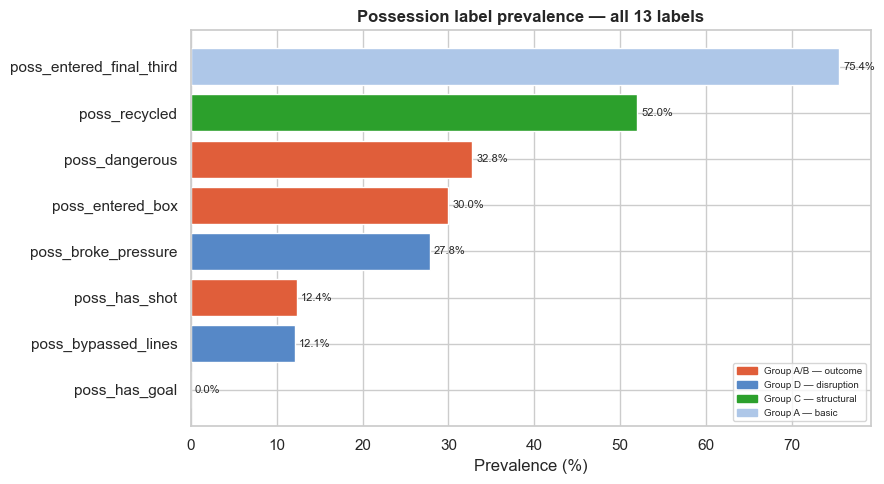

In [9]:
# All label prevalences
bool_labels = [k for k, v in LABEL_DEFINITIONS.items() if v["type"] == "bool" and k in poss.columns]

rates = {col: poss[col].mean() for col in bool_labels}
df_rates = pd.Series(rates).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ["#e05e3a" if "dangerous" in c or "shot" in c or "goal" in c or "box" in c
          else "#5688c7" if "broke" in c or "bypass" in c
          else "#2ca02c" if "recycled" in c
          else "#aec7e8" for c in df_rates.index]
bars = ax.barh(df_rates.index, df_rates.values * 100, color=colors, edgecolor="white")
ax.bar_label(bars, fmt="%.1f%%", padding=3, fontsize=8)
ax.set_xlabel("Prevalence (%)")
ax.set_title("Possession label prevalence — all 13 labels", fontweight="bold")
patches = [
    mpatches.Patch(color="#e05e3a", label="Group A/B — outcome"),
    mpatches.Patch(color="#5688c7", label="Group D — disruption"),
    mpatches.Patch(color="#2ca02c", label="Group C — structural"),
    mpatches.Patch(color="#aec7e8", label="Group A — basic"),
]
ax.legend(handles=patches, fontsize=7, loc="lower right")
plt.tight_layout()
plt.savefig(FIG_DIR / "poss_eda_label_prevalence.png", dpi=150, bbox_inches="tight")
plt.show()

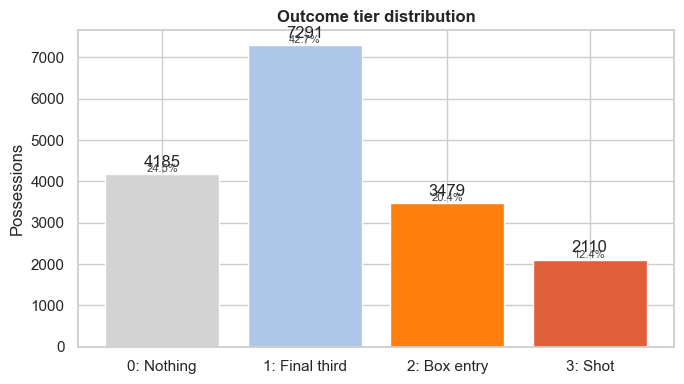

In [10]:
tier_labels = {0: "0: Nothing", 1: "1: Final third", 2: "2: Box entry", 3: "3: Shot"}
tier_counts = poss["poss_outcome_tier"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7, 4))
tier_colors = ["#d3d3d3", "#aec7e8", "#ff7f0e", "#e05e3a"]
bars = ax.bar(
    [tier_labels.get(i, str(i)) for i in tier_counts.index],
    tier_counts.values,
    color=tier_colors[:len(tier_counts)],
    edgecolor="white"
)
ax.bar_label(bars, fmt="%d", padding=3)
ax.set_ylabel("Possessions")
ax.set_title("Outcome tier distribution", fontweight="bold")
for i, (v, c) in enumerate(zip(tier_counts.values, tier_colors)):
    ax.text(i, v + 50, f"{v/len(poss):.1%}", ha="center", fontsize=8, color="#444")
plt.tight_layout()
plt.savefig(FIG_DIR / "poss_eda_outcome_tier.png", dpi=150, bbox_inches="tight")
plt.show()

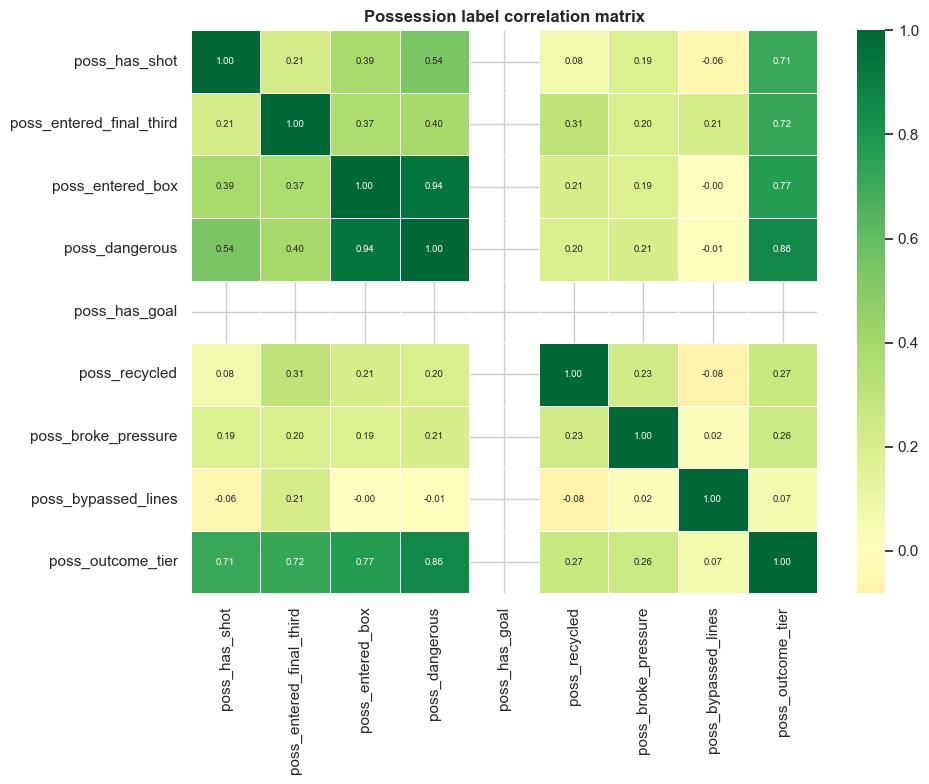

In [11]:
# Label correlation matrix
label_cols_for_corr = bool_labels + ["poss_outcome_tier"]
corr = poss[label_cols_for_corr].astype(float).corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr, annot=True, fmt=".2f", cmap="RdYlGn",
    center=0, linewidths=0.5, ax=ax, annot_kws={"size": 7}
)
ax.set_title("Possession label correlation matrix", fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "poss_eda_label_corr.png", dpi=150, bbox_inches="tight")
plt.show()

In [12]:
# Group labels by LABEL_DEFINITIONS group and print rates
print("Label rates by group:\n")
for grp in ["A", "B", "C", "D"]:
    print(f"  --- Group {grp} ---")
    for col, meta in LABEL_DEFINITIONS.items():
        if meta["group"] != grp or col not in poss.columns:
            continue
        if meta["type"] == "bool":
            print(f"    {col:35s}  {poss[col].mean():.1%}")
        elif meta["type"] in ("float", "int8"):
            s = poss[col].dropna()
            print(f"    {col:35s}  mean={s.mean():.3f}  std={s.std():.3f}")
        else:
            print(f"    {col:35s}  {poss[col].value_counts().to_dict()}")
    print()

Label rates by group:

  --- Group A ---
    poss_has_shot                        12.4%
    poss_entered_final_third             75.4%
    poss_entered_box                     30.0%
    poss_dangerous                       32.8%

  --- Group B ---
    poss_xg_generated                    mean=nan  std=nan
    poss_has_goal                        0.0%
    poss_outcome_tier                    mean=1.206  std=0.949

  --- Group C ---
    poss_tempo                           mean=1.462  std=1.990
    poss_verticality                     mean=1103568.750  std=9067428.000
    poss_recycled                        52.0%
    poss_phase                           {'build_up': 6541, 'progression': 5143, 'counter': 3063, 'final_third': 2318}

  --- Group D ---
    poss_broke_pressure                  27.8%
    poss_bypassed_lines                  12.1%



## 5. Tactical: phase, tempo, verticality, recycling

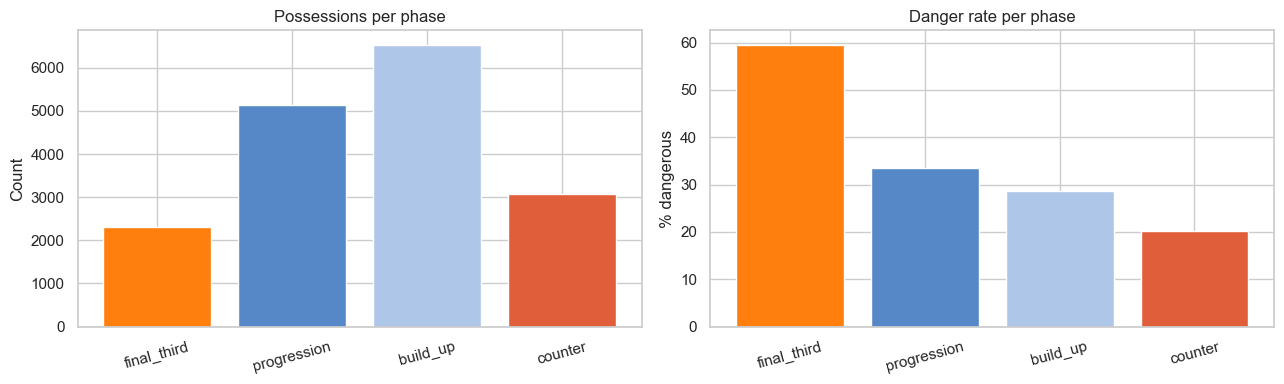

 poss_phase    n  danger_rate  mean_events  mean_tempo  shot_rate  broke_press_rate
final_third 2318     0.595772    22.772217    1.123027   0.254530          0.332183
progression 5143     0.335213    27.236827    1.120562   0.117830          0.321408
   build_up 6541     0.285277    24.040514    1.031125   0.085308          0.298120
    counter 3063     0.201763     7.505387    3.210162   0.116226          0.121123


In [13]:
# Phase distribution + danger rate per phase
phase_stats = poss.groupby("poss_phase", observed=True).agg(
    n=("poss_dangerous", "count"),
    danger_rate=("poss_dangerous", "mean"),
    mean_events=("n_events", "mean"),
    mean_tempo=("poss_tempo", "mean"),
    shot_rate=("poss_has_shot", "mean"),
    broke_press_rate=("poss_broke_pressure", "mean"),
).reset_index().sort_values("danger_rate", ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

phase_colors = {"counter": "#e05e3a", "final_third": "#ff7f0e",
                "progression": "#5688c7", "build_up": "#aec7e8"}
colors = [phase_colors.get(str(p), "gray") for p in phase_stats["poss_phase"]]

ax1.bar(phase_stats["poss_phase"].astype(str), phase_stats["n"], color=colors)
ax1.set_ylabel("Count")
ax1.set_title("Possessions per phase")

ax2.bar(phase_stats["poss_phase"].astype(str), phase_stats["danger_rate"] * 100, color=colors)
ax2.set_ylabel("% dangerous")
ax2.set_title("Danger rate per phase")
for ax in [ax1, ax2]:
    ax.set_xticklabels(phase_stats["poss_phase"].astype(str), rotation=15)

plt.tight_layout()
plt.savefig(FIG_DIR / "poss_eda_phase.png", dpi=150, bbox_inches="tight")
plt.show()
print(phase_stats.to_string(index=False))

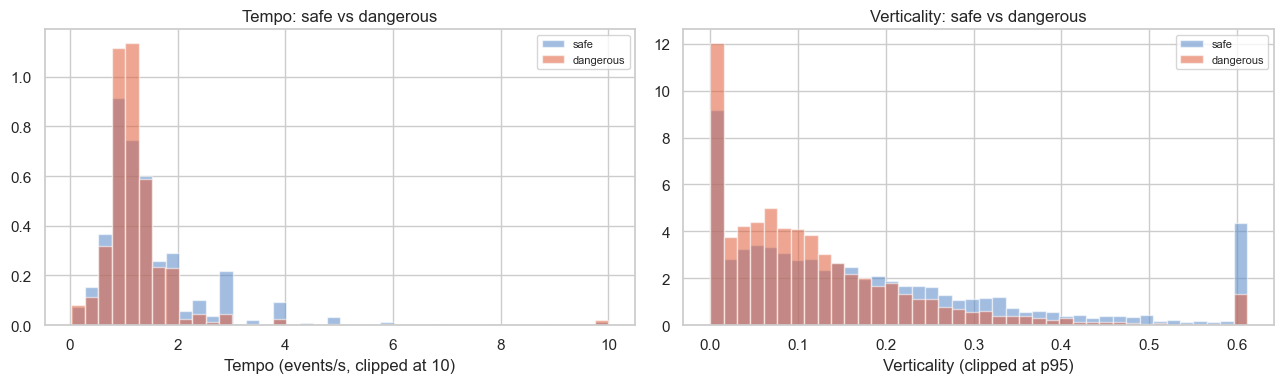

Tempo mean  — safe: 1.480  dangerous: 1.243
Vert  mean  — safe: 0.1827   dangerous: 0.1196


In [14]:
# Tempo vs danger + verticality vs danger
tempo_clip = poss["poss_tempo"].clip(upper=10)   # remove extreme outliers for vis
vert_clip  = poss["poss_verticality"].clip(upper=poss["poss_verticality"].quantile(0.95))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

for ax, series, xlabel in [
    (ax1, tempo_clip, "Tempo (events/s, clipped at 10)"),
    (ax2, vert_clip,  "Verticality (clipped at p95)"),
]:
    safe = series[poss["poss_dangerous"] == False]
    dang = series[poss["poss_dangerous"] == True]
    ax.hist(safe, bins=40, alpha=0.55, label="safe",      density=True, color="#5688c7")
    ax.hist(dang, bins=40, alpha=0.55, label="dangerous", density=True, color="#e05e3a")
    ax.set_xlabel(xlabel)
    ax.legend(fontsize=8)

ax1.set_title("Tempo: safe vs dangerous")
ax2.set_title("Verticality: safe vs dangerous")
plt.tight_layout()
plt.savefig(FIG_DIR / "poss_eda_tempo_vert.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Tempo mean  — safe: {tempo_clip[poss['poss_dangerous']==False].mean():.3f}  "
      f"dangerous: {tempo_clip[poss['poss_dangerous']==True].mean():.3f}")
print(f"Vert  mean  — safe: {vert_clip[poss['poss_dangerous']==False].mean():.4f}   "
      f"dangerous: {vert_clip[poss['poss_dangerous']==True].mean():.4f}")

Possession recycling analysis:
                 n  danger_rate  mean_events  shot_rate  box_rate
Not recycled  8192     0.229248    11.530029   0.097534  0.201660
Recycled      8873     0.418235    31.404147   0.147752  0.390398


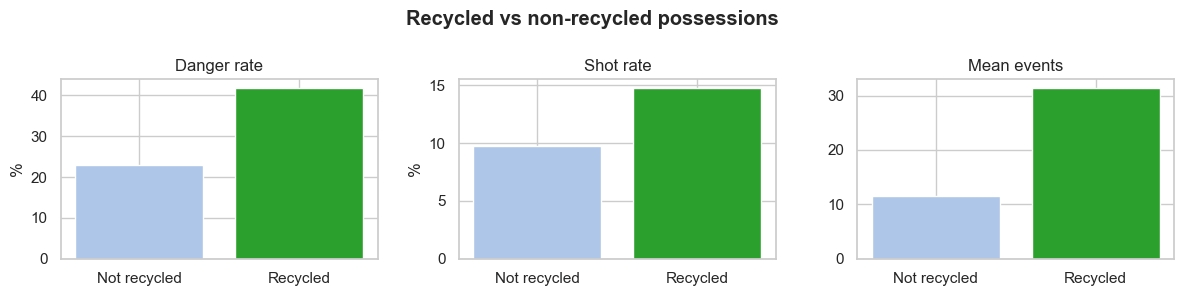

In [15]:
# Recycled vs non-recycled: are recycled possessions more dangerous?
r_stats = poss.groupby("poss_recycled").agg(
    n=("poss_dangerous", "count"),
    danger_rate=("poss_dangerous", "mean"),
    mean_events=("n_events", "mean"),
    shot_rate=("poss_has_shot", "mean"),
    box_rate=("poss_entered_box", "mean"),
)
r_stats.index = ["Not recycled", "Recycled"]
print("Possession recycling analysis:")
print(r_stats.to_string())

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
metrics = [("danger_rate", "Danger rate"), ("shot_rate", "Shot rate"), ("mean_events", "Mean events")]
for ax, (col, title) in zip(axes, metrics):
    ax.bar(r_stats.index, r_stats[col] * (100 if "rate" in col else 1),
           color=["#aec7e8", "#2ca02c"], edgecolor="white")
    ax.set_title(title)
    if "rate" in col:
        ax.set_ylabel("%")
plt.suptitle("Recycled vs non-recycled possessions", fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "poss_eda_recycled.png", dpi=150, bbox_inches="tight")
plt.show()

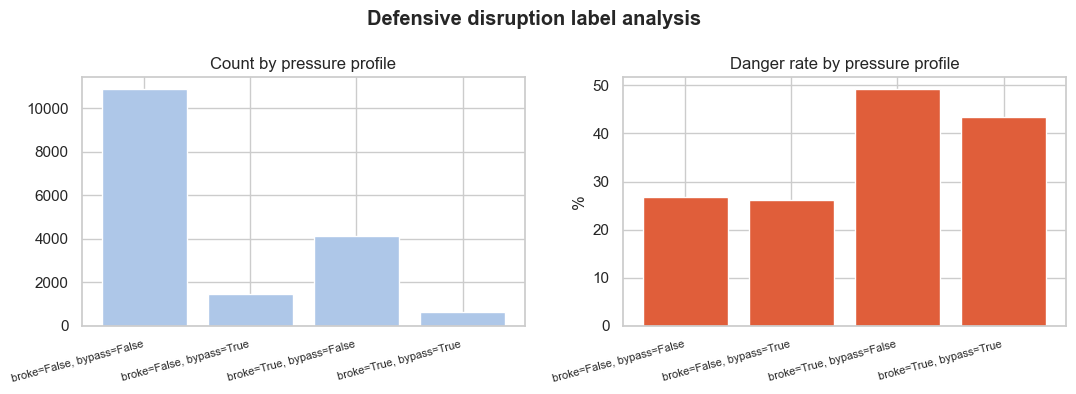

                    label     n  danger_rate
broke=False, bypass=False 10867     0.267967
 broke=False, bypass=True  1454     0.261348
 broke=True, bypass=False  4128     0.491764
  broke=True, bypass=True   616     0.433442


In [16]:
# Pressing analysis: broke_pressure vs bypassed_lines
press_stats = poss.groupby(["poss_broke_pressure", "poss_bypassed_lines"]).agg(
    n=("poss_dangerous", "count"),
    danger_rate=("poss_dangerous", "mean"),
).reset_index()
press_stats["label"] = press_stats.apply(
    lambda r: f"broke={r['poss_broke_pressure']}, bypass={r['poss_bypassed_lines']}", axis=1
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.bar(press_stats["label"], press_stats["n"], color="#aec7e8")
ax1.set_title("Count by pressure profile")
ax1.set_xticklabels(press_stats["label"], rotation=15, ha="right", fontsize=8)

ax2.bar(press_stats["label"], press_stats["danger_rate"] * 100, color="#e05e3a")
ax2.set_title("Danger rate by pressure profile")
ax2.set_ylabel("%")
ax2.set_xticklabels(press_stats["label"], rotation=15, ha="right", fontsize=8)

plt.suptitle("Defensive disruption label analysis", fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "poss_eda_pressure_labels.png", dpi=150, bbox_inches="tight")
plt.show()
print(press_stats[["label", "n", "danger_rate"]].to_string(index=False))

## 6. Origin type & team / competition profiles

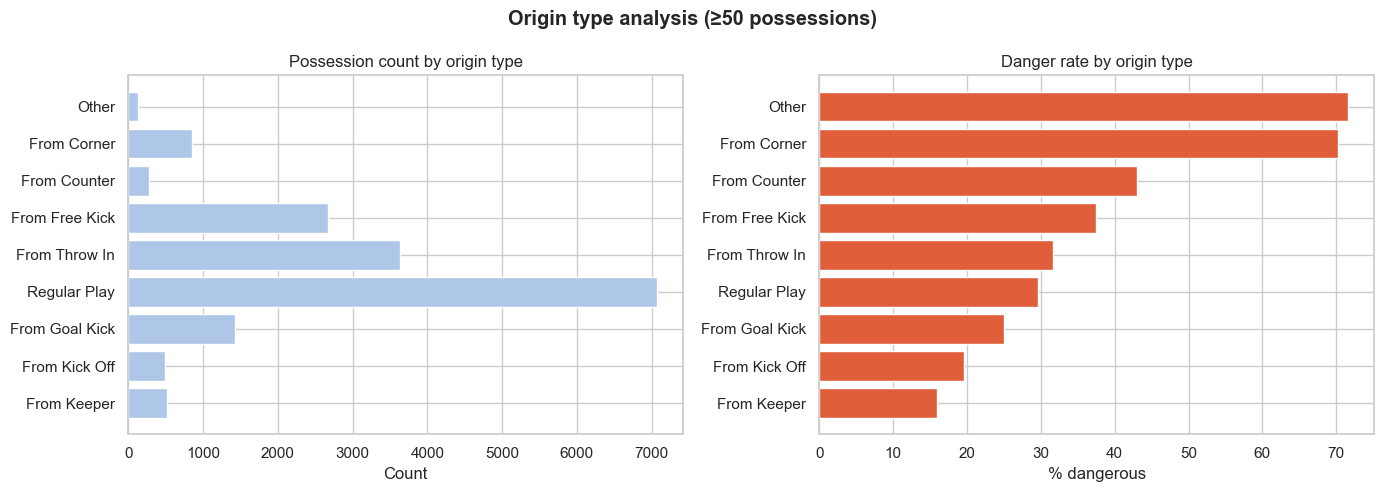

                   n  danger_rate  shot_rate  bypass_rate
origin_type                                              
Other            123     0.715447   0.626016     0.048780
From Corner      856     0.702103   0.352804     0.000000
From Counter     281     0.430605   0.295374     0.220641
From Free Kick  2673     0.374111   0.153386     0.110363
From Throw In   3632     0.316079   0.109306     0.065529
Regular Play    7066     0.296773   0.095811     0.168412
From Goal Kick  1423     0.249473   0.080112     0.140548
From Kick Off    489     0.196319   0.049080     0.000000
From Keeper      522     0.159004   0.049808     0.151341


In [17]:
# Danger rate by origin type — top 12
origin_stats = poss.groupby("origin_type").agg(
    n=("poss_dangerous", "count"),
    danger_rate=("poss_dangerous", "mean"),
    shot_rate=("poss_has_shot", "mean"),
    bypass_rate=("poss_bypassed_lines", "mean"),
).query("n >= 50").sort_values("danger_rate", ascending=False).head(12)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.barh(origin_stats.index[::-1], origin_stats["n"].values[::-1], color="#aec7e8")
ax1.set_xlabel("Count")
ax1.set_title("Possession count by origin type")

ax2.barh(origin_stats.index[::-1], origin_stats["danger_rate"].values[::-1] * 100, color="#e05e3a")
ax2.set_xlabel("% dangerous")
ax2.set_title("Danger rate by origin type")

plt.suptitle("Origin type analysis (≥50 possessions)", fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "poss_eda_origin.png", dpi=150, bbox_inches="tight")
plt.show()
print(origin_stats.to_string())

Teams with ≥100 possessions: 50

               n_poss  danger_rate  shot_rate  broke_press_rate  bypass_rate  mean_tempo
team_name                                                                               
Germany           282     0.425532   0.202128          0.322695     0.102837    1.307956
Real Madrid       152     0.421053   0.164474          0.388158     0.190789    1.596335
Brazil            470     0.414894   0.191489          0.257447     0.100000    1.609608
Barcelona        3216     0.411381   0.157649          0.286070     0.099502    1.497586
Spain             373     0.391421   0.128686          0.278820     0.096515    1.455126
England           395     0.372152   0.146835          0.308861     0.106329    1.603936
Getafe            119     0.361345   0.100840          0.218487     0.100840    1.310140
Villarreal        170     0.341176   0.094118          0.341176     0.111765    1.358206
Denmark           267     0.340824   0.112360          0.295880     0.074906 

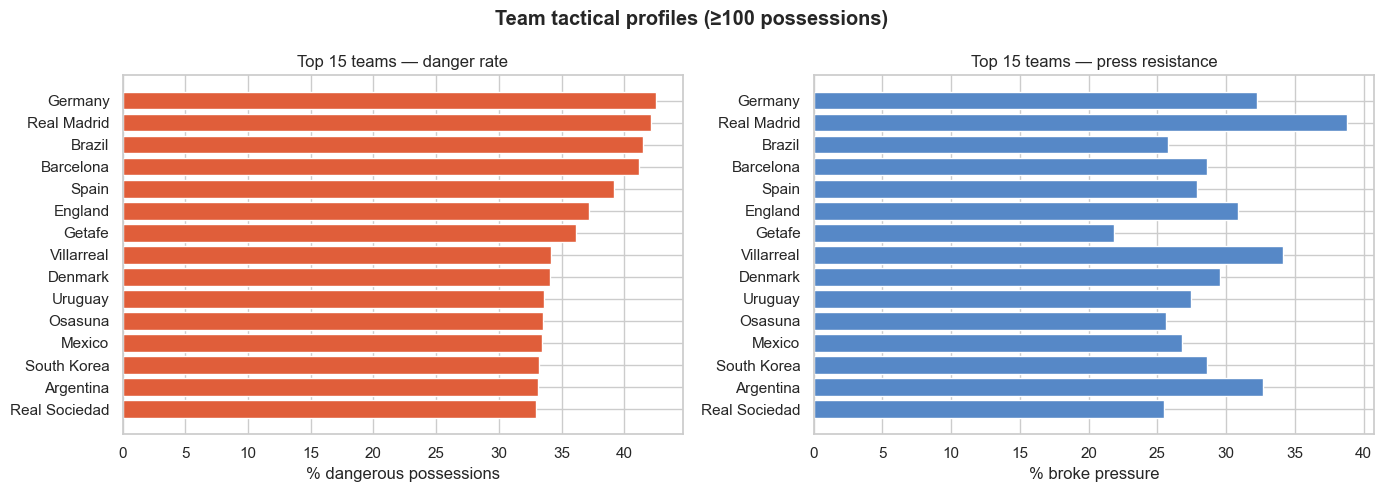

In [18]:
# Top teams by volume and danger rate
team_stats = poss.groupby("team_name").agg(
    n_poss=("poss_dangerous", "count"),
    danger_rate=("poss_dangerous", "mean"),
    shot_rate=("poss_has_shot", "mean"),
    broke_press_rate=("poss_broke_pressure", "mean"),
    bypass_rate=("poss_bypassed_lines", "mean"),
    mean_tempo=("poss_tempo", "mean"),
).query("n_poss >= 100").sort_values("danger_rate", ascending=False)

print(f"Teams with ≥100 possessions: {len(team_stats)}")
print()
print(team_stats.head(15).to_string())

top15 = team_stats.head(15)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(top15.index[::-1], top15["danger_rate"].values[::-1] * 100, color="#e05e3a")
axes[0].set_xlabel("% dangerous possessions")
axes[0].set_title("Top 15 teams — danger rate")

axes[1].barh(top15.index[::-1], top15["broke_press_rate"].values[::-1] * 100, color="#5688c7")
axes[1].set_xlabel("% broke pressure")
axes[1].set_title("Top 15 teams — press resistance")

plt.suptitle("Team tactical profiles (≥100 possessions)", fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "poss_eda_teams.png", dpi=150, bbox_inches="tight")
plt.show()

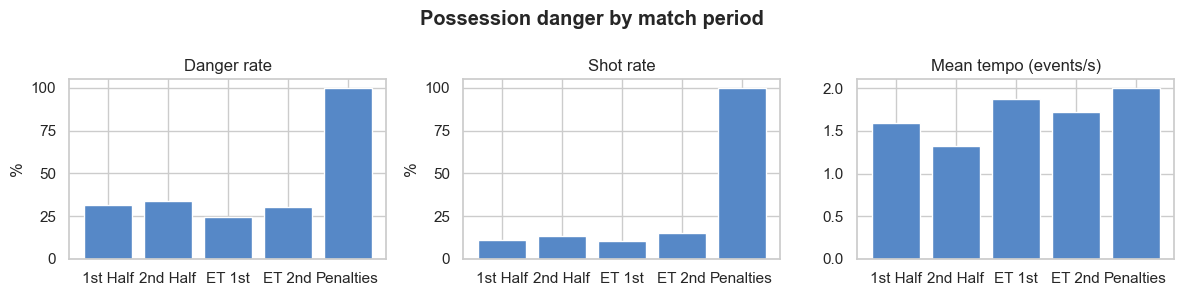

In [19]:
# Danger rate by match period
period_stats = poss.groupby("period").agg(
    n=("poss_dangerous", "count"),
    danger_rate=("poss_dangerous", "mean"),
    shot_rate=("poss_has_shot", "mean"),
    tempo=("poss_tempo", "mean"),
)
period_labels = {1: "1st Half", 2: "2nd Half", 3: "ET 1st", 4: "ET 2nd", 5: "Penalties"}
period_stats.index = [period_labels.get(p, str(p)) for p in period_stats.index]

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for ax, (col, title, scale) in zip(axes, [
    ("danger_rate", "Danger rate", 100),
    ("shot_rate",   "Shot rate",   100),
    ("tempo",       "Mean tempo (events/s)", 1),
]):
    ax.bar(period_stats.index, period_stats[col] * scale, color="#5688c7", edgecolor="white")
    ax.set_title(title)
    if scale == 100:
        ax.set_ylabel("%")

plt.suptitle("Possession danger by match period", fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "poss_eda_period.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Sequence-level: event type distributions across possession steps

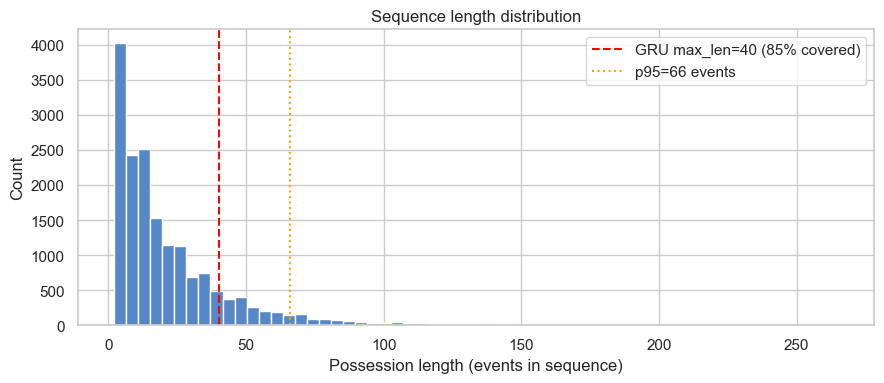

In [20]:
# Distribution of sequence lengths
seq_lens = poss["event_sequence"].apply(len)

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(seq_lens, bins=60, color="#5688c7", edgecolor="white")
for p, lw, ls, col in [(40, 1.5, "--", "red"), (75, 1.5, ":", "orange")]:
    pv = np.percentile(seq_lens, p / (1 if p <= 50 else 1))
pv40 = np.percentile(seq_lens, 75)  # p75
pv95 = np.percentile(seq_lens, 95)
ax.axvline(40,    color="red",    linestyle="--", linewidth=1.5, label=f"GRU max_len=40 ({(seq_lens<=40).mean():.0%} covered)")
ax.axvline(pv95,  color="orange", linestyle=":",  linewidth=1.5, label=f"p95={pv95:.0f} events")
ax.set_xlabel("Possession length (events in sequence)")
ax.set_ylabel("Count")
ax.set_title("Sequence length distribution")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "poss_eda_seq_lengths.png", dpi=150, bbox_inches="tight")
plt.show()

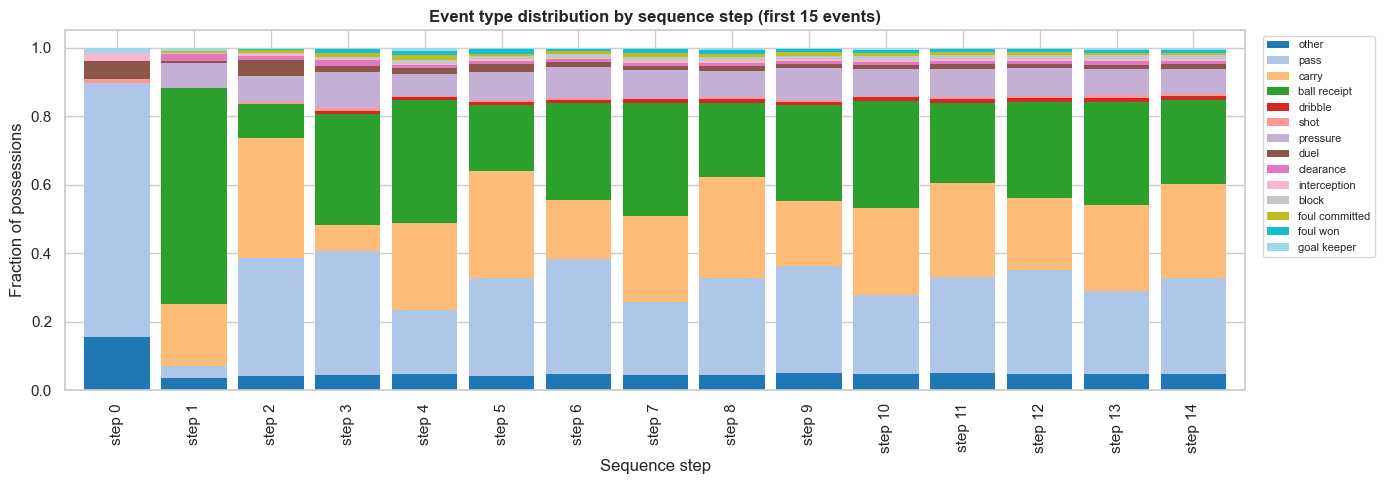

In [21]:
# Most common event types at each step position (step 0-14)
from src.data.parse_possessions import TYPE_VOCAB

ID_TO_TYPE = {v: k for k, v in TYPE_VOCAB.items() if not k.endswith("*")}
ID_TO_TYPE[0] = "other"

MAX_STEP = 15
type_by_step = {step: [] for step in range(MAX_STEP)}

for seq in poss["event_sequence"]:
    for i, evt in enumerate(seq[:MAX_STEP]):
        type_by_step[i].append(evt.get("type_id", 0))

# Build a step × type_name matrix
all_type_ids = sorted(ID_TO_TYPE.keys())
step_mat = np.zeros((MAX_STEP, len(all_type_ids)))
for step, ids in type_by_step.items():
    counts = pd.Series(ids).value_counts()
    total  = len(ids)
    for j, tid in enumerate(all_type_ids):
        step_mat[step, j] = counts.get(tid, 0) / total

step_df = pd.DataFrame(step_mat, columns=[ID_TO_TYPE[i] for i in all_type_ids],
                        index=[f"step {i}" for i in range(MAX_STEP)])

fig, ax = plt.subplots(figsize=(14, 5))
step_df.plot(kind="bar", stacked=True, ax=ax, width=0.85,
             colormap="tab20", edgecolor="none")
ax.set_xlabel("Sequence step")
ax.set_ylabel("Fraction of possessions")
ax.set_title("Event type distribution by sequence step (first 15 events)", fontweight="bold")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / "poss_eda_seq_type_by_step.png", dpi=150, bbox_inches="tight")
plt.show()

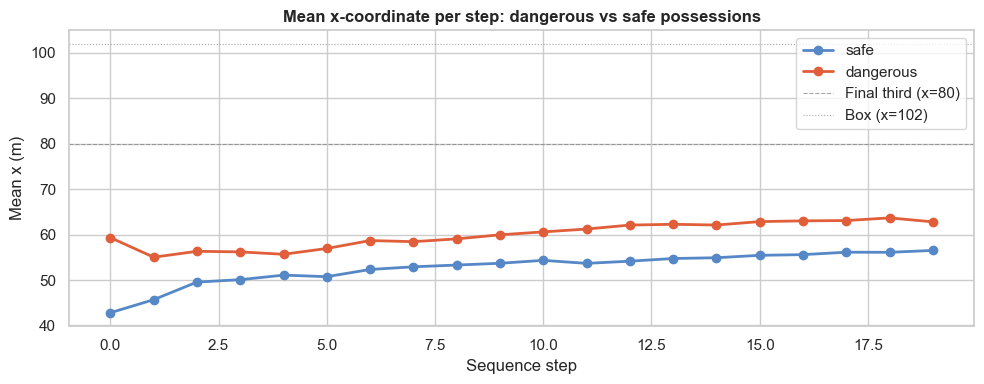

In [22]:
# Mean x-coordinate per step: dangerous vs safe possessions
MAX_STEP_X = 20

mean_x_dang = np.full(MAX_STEP_X, np.nan)
mean_x_safe = np.full(MAX_STEP_X, np.nan)
n_dang = np.zeros(MAX_STEP_X)
n_safe = np.zeros(MAX_STEP_X)

for _, row in poss.iterrows():
    seq = row["event_sequence"] or []
    is_dang = bool(row["poss_dangerous"])
    for i, evt in enumerate(seq[:MAX_STEP_X]):
        x_m = evt.get("loc_x_norm", 0.0) * 120.0
        if is_dang:
            mean_x_dang[i] = np.nansum([mean_x_dang[i] * n_dang[i], x_m]) / (n_dang[i] + 1)
            n_dang[i] += 1
        else:
            mean_x_safe[i] = np.nansum([mean_x_safe[i] * n_safe[i], x_m]) / (n_safe[i] + 1)
            n_safe[i] += 1

steps = np.arange(MAX_STEP_X)
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(steps, mean_x_safe, "o-", color="#5688c7", label="safe",      linewidth=2)
ax.plot(steps, mean_x_dang, "o-", color="#e05e3a", label="dangerous", linewidth=2)
ax.axhline(80,  color="gray", linestyle="--", linewidth=0.8, alpha=0.7, label="Final third (x=80)")
ax.axhline(102, color="gray", linestyle=":",  linewidth=0.8, alpha=0.7, label="Box (x=102)")
ax.set_xlabel("Sequence step")
ax.set_ylabel("Mean x (m)")
ax.set_title("Mean x-coordinate per step: dangerous vs safe possessions", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "poss_eda_x_by_step.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. EDA summary — key findings

In [23]:
print("=" * 65)
print("Possession EDA — Key Findings")
print("=" * 65)

print(f"""
Dataset
  {len(poss):,} possessions  |  {poss['match_id'].nunique()} matches  |  {poss['team_name'].nunique()} teams

Sequence length
  Median {poss['n_events'].median():.0f} events  |  p75={np.percentile(poss['n_events'],75):.0f}  p95={np.percentile(poss['n_events'],95):.0f}
  GRU max_len=40 covers {(poss['n_events']<=40).mean():.1%} of possessions

Label rates
  poss_dangerous          : {poss['poss_dangerous'].mean():.1%}
  poss_has_shot           : {poss['poss_has_shot'].mean():.1%}
  poss_entered_box        : {poss['poss_entered_box'].mean():.1%}
  poss_entered_final_third: {poss['poss_entered_final_third'].mean():.1%}
  poss_broke_pressure     : {poss['poss_broke_pressure'].mean():.1%}
  poss_bypassed_lines     : {poss['poss_bypassed_lines'].mean():.1%}
  poss_recycled           : {poss['poss_recycled'].mean():.1%}

Phase distribution
""")
for phase, cnt in poss['poss_phase'].value_counts().items():
    dr = poss[poss['poss_phase']==phase]['poss_dangerous'].mean()
    print(f"  {str(phase):15s}: {cnt:5,} possessions  |  danger_rate={dr:.1%}")

print(f"""
Model implications
  XGBoost possession baseline : ROC-AUC=0.9479
  GRU sequence (60 epochs)    : ROC-AUC=0.9536
  → GRU edges XGBoost; new labels (poss_phase, poss_broke_pressure)
    should be used as features in next training run
  → poss_outcome_tier enables ordinal regression (richer signal)
  → poss_xg_generated (needs events_df) gives continuous label option
""")

Possession EDA — Key Findings

Dataset
  17,065 possessions  |  99 matches  |  51 teams

Sequence length
  Median 15 events  |  p75=29  p95=66
  GRU max_len=40 covers 85.4% of possessions

Label rates
  poss_dangerous          : 32.8%
  poss_has_shot           : 12.4%
  poss_entered_box        : 30.0%
  poss_entered_final_third: 75.4%
  poss_broke_pressure     : 27.8%
  poss_bypassed_lines     : 12.1%
  poss_recycled           : 52.0%

Phase distribution

  build_up       : 6,541 possessions  |  danger_rate=28.5%
  progression    : 5,143 possessions  |  danger_rate=33.5%
  counter        : 3,063 possessions  |  danger_rate=20.2%
  final_third    : 2,318 possessions  |  danger_rate=59.6%

Model implications
  XGBoost possession baseline : ROC-AUC=0.9479
  GRU sequence (60 epochs)    : ROC-AUC=0.9536
  → GRU edges XGBoost; new labels (poss_phase, poss_broke_pressure)
    should be used as features in next training run
  → poss_outcome_tier enables ordinal regression (richer signal)
  → p